# Linear drag: trajectory and range (Taylor 2.3)

**Class notebook, PHY 317 (Smith, Fall 2026).** A Python version of Will Raven's *Linear Drag Range* Mathematica notebook. Runs as-is on posit.smith.edu.

Eliminating $t$ from the linear-drag solutions ($y$ up) gives the trajectory
$$y(x) = \frac{v_{y0} + v_{\rm ter}}{v_{x0}}\,x + v_{\rm ter}\,\tau\,\ln\!\left(1 - \frac{x}{v_{x0}\tau}\right),$$
which has a **vertical asymptote at $x = v_{x0}\tau$**: the projectile can never get past it, no matter how long it falls. Setting $y = 0$ gives the range equation, which has no closed-form solution; for small drag Taylor expands the log to get
$$R \approx R_{\rm vac}\left(1 - \frac{4}{3}\frac{v_{y0}}{v_{\rm ter}}\right), \qquad R_{\rm vac} = \frac{2 v_{x0} v_{y0}}{g}.$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

g = 9.8

def trajectory(x, vx0, vy0, tau):
    vter = g * tau
    return (vy0 + vter) / vx0 * x + vter * tau * np.log(1 - x / (vx0 * tau))

def range_exact(vx0, vy0, tau):
    """Solve y(R) = 0 numerically for 0 < R < vx0*tau."""
    xmax = vx0 * tau * (1 - 1e-9)
    return brentq(lambda x: trajectory(x, vx0, vy0, tau), 1e-9 * xmax, xmax)

def range_vacuum(vx0, vy0):
    return 2 * vx0 * vy0 / g

def range_small_drag(vx0, vy0, tau):
    return range_vacuum(vx0, vy0) * (1 - 4 * vy0 / (3 * g * tau))

## Trajectories for several $\tau$, against the vacuum parabola

Small $\tau$ (big drag) pulls the trajectory in hard; the dashed vertical lines are the asymptotes $x = v_{x0}\tau$. Change the launch velocity and `taus`.

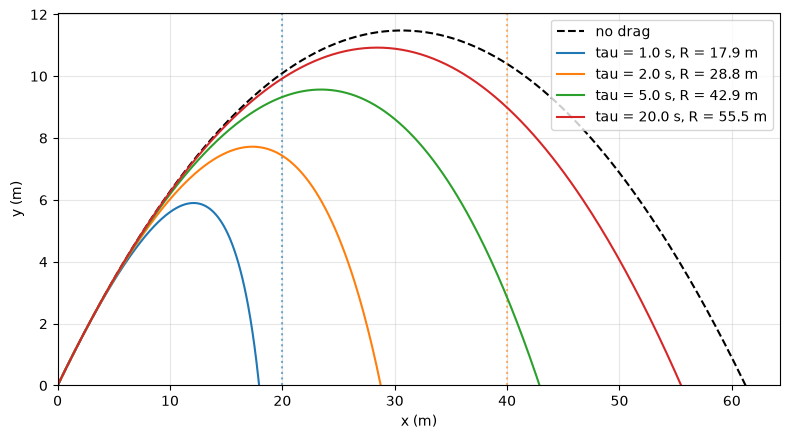

In [2]:
vx0, vy0 = 20.0, 15.0            # m/s
taus = [1.0, 2.0, 5.0, 20.0]     # s

fig, ax = plt.subplots(figsize=(8, 4.5))
xv = np.linspace(0, range_vacuum(vx0, vy0), 300)
ax.plot(xv, vy0 / vx0 * xv - g * xv**2 / (2 * vx0**2), "k--", label="no drag")
for tau in taus:
    R = range_exact(vx0, vy0, tau)
    x = np.linspace(0, R, 300)
    line, = ax.plot(x, trajectory(x, vx0, vy0, tau), label=f"tau = {tau} s, R = {R:.1f} m")
    ax.axvline(vx0 * tau, ls=":", color=line.get_color(), alpha=0.6)
ax.set(xlabel="x (m)", ylabel="y (m)", ylim=(0, None), xlim=(0, range_vacuum(vx0, vy0) * 1.05))
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()

## How good is the small-drag approximation?

Taylor's expansion keeps one correction term in $v_{y0}/v_{\rm ter}$. Compare the exact range with the approximation as drag increases; the approximation is excellent when $v_{y0} \ll v_{\rm ter}$ and falls apart when it is not.

tau =  20.0 s: v_y0/v_ter = 0.077, R_exact/R_vac = 0.906, approx = 0.898
tau =   5.0 s: v_y0/v_ter = 0.306, R_exact/R_vac = 0.701, approx = 0.592
tau =   2.0 s: v_y0/v_ter = 0.765, R_exact/R_vac = 0.470, approx = -0.020


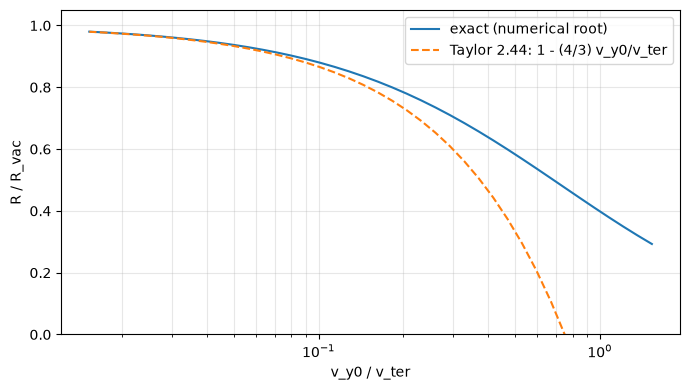

In [3]:
taus = np.logspace(0, 2, 40)     # 1 s .. 100 s
exact = np.array([range_exact(vx0, vy0, t) for t in taus])
approx = np.array([range_small_drag(vx0, vy0, t) for t in taus])
Rv = range_vacuum(vx0, vy0)

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(vy0 / (g * taus), exact / Rv, label="exact (numerical root)")
ax.semilogx(vy0 / (g * taus), approx / Rv, "--", label="Taylor 2.44: 1 - (4/3) v_y0/v_ter")
ax.set(xlabel="v_y0 / v_ter", ylabel="R / R_vac", ylim=(0, 1.05))
ax.legend(); ax.grid(alpha=0.3, which="both")
plt.tight_layout()
for t in (20.0, 5.0, 2.0):
    print(f"tau = {t:5.1f} s: v_y0/v_ter = {vy0/(g*t):.3f}, R_exact/R_vac = {range_exact(vx0, vy0, t)/Rv:.3f}, approx = {range_small_drag(vx0, vy0, t)/Rv:.3f}")